In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.formula.api as smf
from statsmodels.stats.proportion import proportion_confint, proportions_ztest

PROJ = '/content/drive/MyDrive/airline-cx-copilot'
DATA = f'{PROJ}/data'

df = pd.read_parquet(f'{DATA}/reviews_clean.parquet')
print(df.shape)
print(df['overall_rating'].value_counts().sort_index())
assert (df['overall_rating'] == 10).sum() > 1000, 'The 1->10 rating fix is missing from reviews_clean.parquet. Rerun notebook 1 with the fix cells.'

Mounted at /content/drive
(22297, 19)
overall_rating
1.0     9319
2.0     2294
3.0     1353
4.0      853
5.0      826
6.0      672
7.0     1193
8.0     1756
9.0     1767
10.0    2264
Name: count, dtype: int64


Overall recommend rate: 0.350  (n = 22297)

                  sum  count   rate  ci_low  ci_high
seat_type                                           
Economy Class    6293  18836  0.334   0.327    0.341
Premium Economy   222    646  0.344   0.308    0.381
Business Class   1139   2077  0.548   0.527    0.570
First Class       108    185  0.584   0.512    0.652


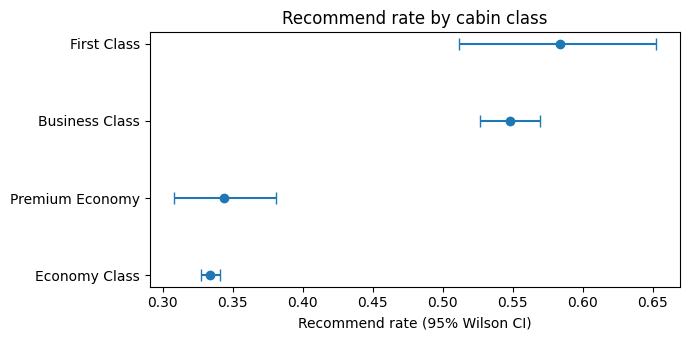

In [2]:
def wilson(k, n):
    lo, hi = proportion_confint(int(k), int(n), method='wilson')
    return lo, hi

results = []   # collects test results for the summary file

p_all = df['recommended_bin'].mean()
print(f'Overall recommend rate: {p_all:.3f}  (n = {len(df)})\n')

g = df.dropna(subset=['seat_type']).groupby('seat_type')['recommended_bin'].agg(['sum', 'count'])
g['rate'] = g['sum'] / g['count']
g[['ci_low', 'ci_high']] = [wilson(k, n) for k, n in zip(g['sum'], g['count'])]
g = g.sort_values('rate')
print(g.round(3))

plt.figure(figsize=(7, 3.5))
plt.errorbar(g['rate'], range(len(g)), xerr=[g['rate'] - g['ci_low'], g['ci_high'] - g['rate']], fmt='o', capsize=4)
plt.yticks(range(len(g)), g.index)
plt.xlabel('Recommend rate (95% Wilson CI)')
plt.title('Recommend rate by cabin class')
plt.tight_layout()
plt.show()

In [3]:
# --- Is recommend rate different across cabin classes? ---
tab = pd.crosstab(df['seat_type'], df['recommended_bin'])
chi2, p, dof, _ = stats.chi2_contingency(tab)
cramers_v = np.sqrt(chi2 / (tab.values.sum() * (min(tab.shape) - 1)))
print(f'Chi-square test, cabin class vs recommended: chi2={chi2:.1f}, dof={dof}, p={p:.2e}, Cramer V={cramers_v:.3f}')
results.append({'test': 'chi-square cabin class vs recommended', 'statistic': round(chi2, 1), 'p_value': p, 'effect_size': round(cramers_v, 3)})

# --- Premium cabins vs Economy: difference in proportions with bootstrap CI ---
rng = np.random.default_rng(42)
prem = df.loc[df['seat_type'].isin(['Business Class', 'First Class']), 'recommended_bin'].values
econ = df.loc[df['seat_type'] == 'Economy Class', 'recommended_bin'].values
diff = prem.mean() - econ.mean()
boots = np.array([rng.choice(prem, len(prem)).mean() - rng.choice(econ, len(econ)).mean() for _ in range(2000)])
lo, hi = np.percentile(boots, [2.5, 97.5])
z, pz = proportions_ztest([prem.sum(), econ.sum()], [len(prem), len(econ)])
print(f'Business/First minus Economy recommend rate: {diff:+.3f}  (95% bootstrap CI {lo:+.3f} to {hi:+.3f}), z-test p={pz:.2e}')
results.append({'test': 'premium (Business/First) minus Economy recommend rate', 'statistic': round(diff, 3),
                'p_value': pz, 'effect_size': f'95% CI [{lo:+.3f}, {hi:+.3f}]'})

Chi-square test, cabin class vs recommended: chi2=416.4, dof=3, p=6.08e-90, Cramer V=0.138
Business/First minus Economy recommend rate: +0.217  (95% bootstrap CI +0.195 to +0.238), z-test p=3.33e-92


In [4]:
# --- Overall rating by traveller type (ratings are skewed, so use rank-based tests) ---
d = df.dropna(subset=['type_of_traveller'])
groups = [x['overall_rating'].values for _, x in d.groupby('type_of_traveller')]
H, p = stats.kruskal(*groups)
k, n = len(groups), len(d)
eps2 = (H - k + 1) / (n - k)
print(d.groupby('type_of_traveller')['overall_rating'].agg(['count', 'median', 'mean']).round(2))
print(f'\nKruskal-Wallis, rating by traveller type: H={H:.1f}, p={p:.2e}, epsilon^2={eps2:.4f}')
results.append({'test': 'Kruskal-Wallis rating by traveller type', 'statistic': round(H, 1), 'p_value': p, 'effect_size': round(eps2, 4)})

# --- Verified vs unverified reviews ---
ver = df['verified'].astype(str).str.lower().eq('true')
u, pu = stats.mannwhitneyu(df.loc[ver, 'overall_rating'], df.loc[~ver, 'overall_rating'], alternative='two-sided')
auc_like = u / (ver.sum() * (~ver).sum())
print(f'\nMann-Whitney, verified vs unverified rating: p={pu:.2e}, P(verified > unverified)={auc_like:.3f}')
print('Median rating  verified:', df.loc[ver, 'overall_rating'].median(), '| unverified:', df.loc[~ver, 'overall_rating'].median())
results.append({'test': 'Mann-Whitney verified vs unverified rating', 'statistic': round(u, 0), 'p_value': pu, 'effect_size': round(auc_like, 3)})

                   count  median  mean
type_of_traveller                     
Business            2694     2.0  3.88
Couple Leisure      5262     2.0  3.55
Family Leisure      4350     1.0  3.42
Solo Leisure        7114     2.0  4.09

Kruskal-Wallis, rating by traveller type: H=131.6, p=2.41e-28, epsilon^2=0.0066

Mann-Whitney, verified vs unverified rating: p=4.71e-86, P(verified > unverified)=0.427
Median rating  verified: 2.0 | unverified: 3.0


Complete cases: 13094 of 22297 reviews  (wifi and inflight entertainment are excluded: mostly missing)
                                                                             odds_ratio  ci_low  ci_high  p_value
C(seat_type, Treatment(reference="Economy Class"))[T.Business Class]             0.9156  0.7185   1.1667   0.4757
C(seat_type, Treatment(reference="Economy Class"))[T.First Class]                1.1125  0.4848   2.5530   0.8014
C(seat_type, Treatment(reference="Economy Class"))[T.Premium Economy]            0.5791  0.3756   0.8929   0.0134
C(type_of_traveller, Treatment(reference="Solo Leisure"))[T.Business]            0.8590  0.6693   1.1025   0.2326
C(type_of_traveller, Treatment(reference="Solo Leisure"))[T.Couple Leisure]      0.8575  0.6917   1.0630   0.1608
C(type_of_traveller, Treatment(reference="Solo Leisure"))[T.Family Leisure]      0.7751  0.6153   0.9764   0.0306
seat_comfort                                                                     1.4984  1.3798   1

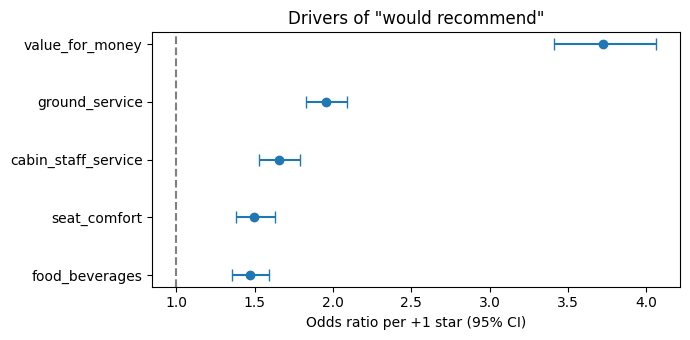

In [5]:
# overall_rating is excluded on purpose: it nearly determines "recommended"
feat = ['seat_comfort', 'cabin_staff_service', 'food_beverages', 'ground_service', 'value_for_money']
d = df.dropna(subset=feat + ['recommended_bin', 'seat_type', 'type_of_traveller']).copy()
print(f'Complete cases: {len(d)} of {len(df)} reviews  (wifi and inflight entertainment are excluded: mostly missing)')

ref_seat = 'Economy Class' if (d['seat_type'] == 'Economy Class').any() else d['seat_type'].mode()[0]
ref_trav = d['type_of_traveller'].mode()[0]
formula = ('recommended_bin ~ ' + ' + '.join(feat) +
           f' + C(seat_type, Treatment(reference="{ref_seat}"))' +
           f' + C(type_of_traveller, Treatment(reference="{ref_trav}"))')
model = smf.logit(formula, data=d).fit(disp=False)

ci = model.conf_int()
or_table = pd.DataFrame({'odds_ratio': np.exp(model.params), 'ci_low': np.exp(ci[0]), 'ci_high': np.exp(ci[1]), 'p_value': model.pvalues})
or_table = or_table.drop('Intercept').round(4)
print(or_table.to_string())
print(f'\nMcFadden pseudo R^2: {model.prsquared:.3f}')

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
X = pd.get_dummies(d[feat + ['seat_type', 'type_of_traveller']], drop_first=True).astype(float)
auc = cross_val_score(LogisticRegression(max_iter=2000), X, d['recommended_bin'], cv=5, scoring='roc_auc')
print(f'5-fold cross-validated ROC AUC: {auc.mean():.3f} (+/- {auc.std():.3f})')

fo = or_table.loc[feat].sort_values('odds_ratio')
plt.figure(figsize=(7, 3.5))
plt.errorbar(fo['odds_ratio'], range(len(fo)), xerr=[fo['odds_ratio'] - fo['ci_low'], fo['ci_high'] - fo['odds_ratio']], fmt='o', capsize=4)
plt.axvline(1, color='grey', linestyle='--')
plt.yticks(range(len(fo)), fo.index)
plt.xlabel('Odds ratio per +1 star (95% CI)')
plt.title('Drivers of "would recommend"')
plt.tight_layout()
plt.show()
or_table.to_csv(f'{DATA}/odds_ratios.csv')

248 airlines with >= 30 reviews; median reviews per airline: 100
Typical 95% CI width: 0.19 (i.e. +/- 0.09)
Airlines significantly different from the overall rate (FDR-adjusted p<0.05): 167 of 248

Lowest 5:
                   count   rate  ci_low  ci_high  p_adj
airline_name                                           
Viva Air              70  0.014   0.003    0.077    0.0
Avianca              100  0.020   0.006    0.070    0.0
Frontier Airlines    100  0.020   0.006    0.070    0.0
Interjet             100  0.020   0.006    0.070    0.0
Jetblue Airways      100  0.030   0.010    0.085    0.0

Highest 5:
                         count   rate  ci_low  ci_high  p_adj
airline_name                                                 
Cathay Dragon               62  0.823   0.710    0.898    0.0
Hainan Airlines            100  0.870   0.790    0.922    0.0
BA CityFlyer                71  0.873   0.776    0.932    0.0
Lao Airlines                72  0.903   0.813    0.952    0.0
China Southern A

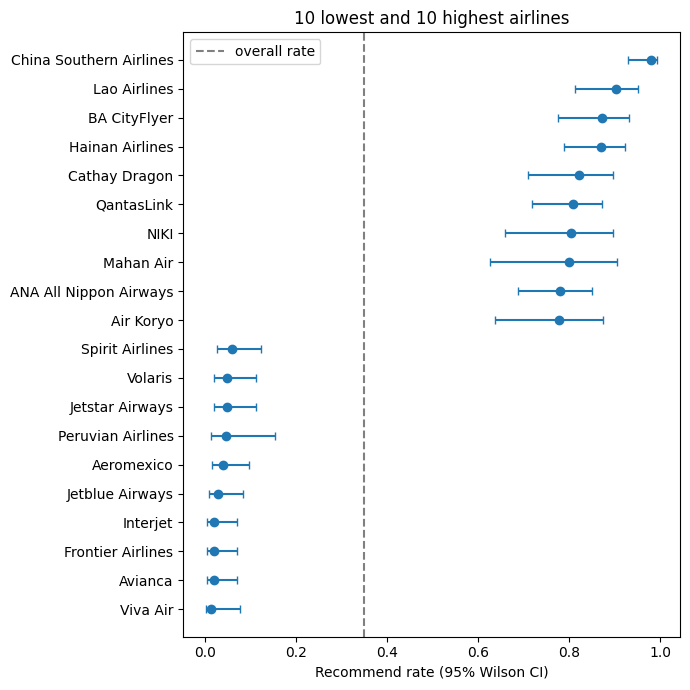

In [6]:
from statsmodels.stats.multitest import multipletests

a = df.groupby('airline_name')['recommended_bin'].agg(['sum', 'count'])
a = a[a['count'] >= 30].copy()
a['rate'] = a['sum'] / a['count']
a[['ci_low', 'ci_high']] = [wilson(k, n) for k, n in zip(a['sum'], a['count'])]
a['p'] = [stats.binomtest(int(k), int(n), p_all).pvalue for k, n in zip(a['sum'], a['count'])]
a['p_adj'] = multipletests(a['p'], method='fdr_bh')[1]
a['differs_from_average'] = a['p_adj'] < 0.05
a = a.sort_values('rate')

print(f'{len(a)} airlines with >= 30 reviews; median reviews per airline: {int(a["count"].median())}')
print(f'Typical 95% CI width: {(a["ci_high"] - a["ci_low"]).median():.2f} (i.e. +/- {(a["ci_high"] - a["ci_low"]).median() / 2:.2f})')
print(f'Airlines significantly different from the overall rate (FDR-adjusted p<0.05): {int(a["differs_from_average"].sum())} of {len(a)}')
print('\nLowest 5:'); print(a.head(5)[['count', 'rate', 'ci_low', 'ci_high', 'p_adj']].round(3))
print('\nHighest 5:'); print(a.tail(5)[['count', 'rate', 'ci_low', 'ci_high', 'p_adj']].round(3))

top = pd.concat([a.head(10), a.tail(10)])
plt.figure(figsize=(7, 7))
plt.errorbar(top['rate'], range(len(top)), xerr=[top['rate'] - top['ci_low'], top['ci_high'] - top['rate']], fmt='o', capsize=3)
plt.axvline(p_all, color='grey', linestyle='--', label='overall rate')
plt.yticks(range(len(top)), top.index)
plt.xlabel('Recommend rate (95% Wilson CI)')
plt.title('10 lowest and 10 highest airlines')
plt.legend()
plt.tight_layout()
plt.show()
a.to_csv(f'{DATA}/airline_stats.csv')

         sum  count   rate  ci_low  ci_high
year                                       
2015.0   472    889  0.531   0.498    0.564
2016.0   572   1155  0.495   0.466    0.524
2017.0   514   1160  0.443   0.415    0.472
2018.0   682   1771  0.385   0.363    0.408
2019.0  1015   2925  0.347   0.330    0.364
2020.0   325   1378  0.236   0.214    0.259
2021.0   274   1022  0.268   0.242    0.296
2022.0   989   4114  0.240   0.228    0.254
2023.0  1244   4978  0.250   0.238    0.262


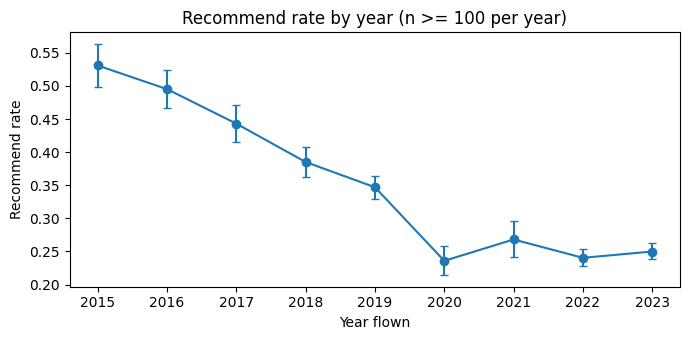

In [7]:
yr = pd.to_datetime(df['date_flown'], errors='coerce').dt.year
t = df.assign(year=yr).dropna(subset=['year']).groupby('year')['recommended_bin'].agg(['sum', 'count'])
t = t[t['count'] >= 100].copy()
t['rate'] = t['sum'] / t['count']
t[['ci_low', 'ci_high']] = [wilson(k, n) for k, n in zip(t['sum'], t['count'])]
print(t.round(3))

plt.figure(figsize=(7, 3.5))
plt.errorbar(t.index, t['rate'], yerr=[t['rate'] - t['ci_low'], t['ci_high'] - t['rate']], fmt='-o', capsize=3)
plt.ylabel('Recommend rate')
plt.xlabel('Year flown')
plt.title('Recommend rate by year (n >= 100 per year)')
plt.tight_layout()
plt.show()

In [8]:
yr = pd.to_datetime(df['date_flown'], errors='coerce').dt.year
d2 = df.assign(year=yr).dropna(subset=['year']).copy()
d2['period'] = np.where(d2['year'] <= 2019, 'pre-2020', np.where(d2['year'] >= 2022, '2022+', 'covid'))
pv = (d2[d2['period'].isin(['pre-2020', '2022+'])]
      .groupby(['airline_name', 'period'])['recommended_bin'].agg(['mean', 'count']).unstack())
pv = pv[(pv[('count', 'pre-2020')] >= 15) & (pv[('count', '2022+')] >= 15)]
chg = pv[('mean', '2022+')] - pv[('mean', 'pre-2020')]
print(len(pv), 'airlines with >= 15 reviews in both periods')
print('mean change in recommend rate:', round(chg.mean(), 3), '| share of airlines that declined:', round((chg < 0).mean(), 2))
print('Wilcoxon signed-rank p =', stats.wilcoxon(chg).pvalue)

results.append({'test': 'Wilcoxon: same-airline change in recommend rate, pre-2020 vs 2022+',
                'statistic': round(chg.mean(), 3), 'p_value': stats.wilcoxon(chg).pvalue,
                'effect_size': f'{len(pv)} airlines, share declined {(chg < 0).mean():.2f}'})

42 airlines with >= 15 reviews in both periods
mean change in recommend rate: -0.048 | share of airlines that declined: 0.6
Wilcoxon signed-rank p = 0.04816942294057708


In [9]:
res = pd.DataFrame(results).drop_duplicates(subset='test', keep='last')
res.to_csv(f'{DATA}/stat_tests_summary.csv', index=False)
print(res.to_string(index=False))
print('\nSaved: odds_ratios.csv, airline_stats.csv, stat_tests_summary.csv')

                                                              test    statistic      p_value                      effect_size
                             chi-square cabin class vs recommended      416.400 6.079761e-90                            0.138
             premium (Business/First) minus Economy recommend rate        0.217 3.325766e-92          95% CI [+0.195, +0.238]
                           Kruskal-Wallis rating by traveller type      131.600 2.412969e-28                           0.0066
                        Mann-Whitney verified vs unverified rating 52432885.000 4.713495e-86                            0.427
Wilcoxon: same-airline change in recommend rate, pre-2020 vs 2022+       -0.048 4.816942e-02 42 airlines, share declined 0.60

Saved: odds_ratios.csv, airline_stats.csv, stat_tests_summary.csv
